# STAT201 · 4-hafta · Kompyuter laboratoriyasi (Python)

### Tasodifiy miqdorlar va diskret taqsimotlar

**Toshkent Xalqaro Universiteti · Iqtisodiyot fakulteti · 2025/2026**

---

**Maqsad.** Maʼruzada keltirib chiqarilgan **ehtimollik massasi funksiyasi**,
**taqsimot funksiyasi**, **matematik kutilma** va **dispersiya**ni haqiqiy
maʼlumot ustida *birinchi tamoyillardan* qurish; soʻng ikkita nomlangan
taqsimotning — binomial va Puassonning — **shartlarini tekshirib**, qaysi
biri qayerda qoʻllanishini *maʼlumot bilan* hal qilish.

**Haftaning markaziy gʻoyasi — shartni tekshirmasdan taqsimot tanlanmaydi.**
Bugun *bitta* maʼlumot toʻplamidan bir nechta sanoq oʻzgaruvchisi olamiz.
Ularning hammasi «sanoq», hammasi butun son, hammasi manfiy emas — ammo
Puasson modeli ularning faqat bir qismiga mos keladi. Taqsimotni
**maʼlumot turi emas, jarayon sharti** belgilaydi.

> **Qoida.** Har bir taqsimotning tekshiriladigan sharti bor: binomial uchun
> **BINS**, Puasson uchun $s^2/\bar{x} \approx 1$. Shartni tekshirmasdan
> qoʻllangan model xato javob beradi va *hech qanday ogohlantirish bermaydi*.

**Ish zanjiri.** Har bir topshiriqda quyidagi ketma-ketlikni yozma ravishda
bajarasiz:

> **statistik tushuncha → maʼlumot → kod → natija → talqin → qaror**

Faqat kod yozib, natijani izohsiz qoldirish — topshiriq bajarilmagan
hisoblanadi. Baholashning yarmidan koʻpi aynan *talqin* va *qaror*
bosqichlariga beriladi.

**Vaqt va ball taqsimoti (120 daqiqa, 110 ball + 5 bonus).**

| # | Mazmun | Daqiqa | Blum | Ball |
|---|---|---|---|---|
| 0 | Muhitni sozlash | 5 | — | — |
| 1 | Ehtimollik massasi funksiyasi va taqsimot funksiyasi | 20 | Qoʻllash | 20 |
| 2 | Matematik kutilma va dispersiya: yigʻindi va yopiq shakl | 20 | Qoʻllash | 20 |
| 3 | Takroriy tanlash: empirik taqsimot va cheklangan toʻplam tuzatmasi | 25 | Tahlil | 25 |
| 4 | Dispersiya/oʻrtacha nisbati: Puasson qayerda mos keladi | 25 | Baholash | 25 |
| 5 | Puasson — binomialning limiti | 20 | Tahlil | 20 |
| 6 | Ixtiyoriy: sugʻurta, dispersiya va $\sqrt{n}$ qonuni | uyda | Yaratish | +5 |

**Oldingi bilim (2- va 3-hafta).** Hodisani **mantiqiy (boolean) seriya**
sifatida ifodalash (`A.sum()` $= n(A)$, `A.mean()` $= \Pr(A)$);
kombinatsiyalar soni $\binom{n}{x}$ (`math.comb`); bogʻliqsizlik taʼrifi;
MINSTD generatori va urugʻ tushunchasi; ishchi fazo $|S| = 2\,458$ va nima
uchun $2\,467$ emas.

## 0-bosqich. Muhitni sozlash

In [1]:
# --- Kerakli kutubxonalar --------------------------------------------
# pandas     — jadval koʻrinishidagi maʼlumot (DataFrame)
# numpy      — sonli massivlar va vektor amallari
# matplotlib — grafiklar
# math       — comb(), factorial(), exp(), sqrt()
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from math import comb, exp, factorial, sqrt

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__)

%matplotlib inline

pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.9


In [2]:
# --- Grafiklarda oʻzbekcha «ʻ» belgisi (U+02BB) ----------------------
# QOIDA (2-haftadan): grafik yorliqlarida faqat ASCII harflar — shunda
# natija har qanday muhitda, jumladan R ning standart pdf() qurilmasida
# ham, buzilmaydi.
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

# --- Okabe-Ito palitrasi (rang koʻrmaslikka moslashgan) ---------------
oiBlue, oiOrange, oiGreen = "#0072B2", "#E69F00", "#009E73"
oiPink, oiVerm,   oiSky   = "#CC79A7", "#D55E00", "#56B4E9"

In [3]:
# --- Asosiy maʼlumot va ISHCHI FAZO -----------------------------------
# 2-haftadagi qaror oʻzgarmaydi: reytingi koʻrsatilmagan 9 ta film
# fazodan chiqariladi, chunki ular uchun «R reyting» hodisasi
# aniqlanmagan. |S| = 2458.
kino = pd.read_csv("data/kinolar-byudjet.csv", encoding="utf-8")
kino_t = kino.dropna(subset=["reyting"]).reset_index(drop=True)
N_pop = len(kino_t)

# Hodisa = mantiqiy seriya (2-hafta). «R» — ASCII satr, lokal tuzogʻi yoʻq.
# QOIDA: toifa nomlarini kod ichida literal yozmang — ularni sorted(unique())
# orqali FAYLDAN oling. «R» va «Horror» ASCII boʻlgani uchun bu yerda xavfsiz.
R_bayroq = (kino_t["reyting"] == "R").to_numpy().astype(int)
K_pop = int(R_bayroq.sum())
p = K_pop / N_pop

print("xom satrlar          :", len(kino))
print("reytingi yoʻq        :", len(kino) - N_pop)
print("ISHCHI FAZO |S| = N  :", N_pop)
print("R reytinglilar K     :", K_pop)
print("p = K/N              : %.10f" % p)

xom satrlar          : 2467
reytingi yoʻq        : 9
ISHCHI FAZO |S| = N  : 2458
R reytinglilar K     : 1113
p = K/N              : 0.4528071603


**Bugungi tasodifiy miqdor.** $2\,458$ ta filmdan **10 tasi tasodifiy
tanlanadi**. $X$ — tanlangan oʻntalikdagi R reytingli filmlar soni.
Bu — 3-haftadagi *hodisa* ($R$) ning *songa* aylantirilishi:
$X: S \to \{0, 1, \dots, 10\}$.

---
## 1-topshiriq. Ehtimollik massasi funksiyasi va taqsimot funksiyasi

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball · 20 daqiqa**

### Statistik tushuncha

**Ehtimollik massasi funksiyasi** *(probability mass function)*:
$$p(x) = \Pr(X = x).$$
Ikkita shart bajarilishi **shart**:

1. $p(x) \ge 0$ har bir $x$ uchun;
2. $\sum_x p(x) = 1$.

**Taqsimot funksiyasi** *(cumulative distribution function)*:
$$F(x) = \Pr(X \le x) = \sum_{t \le x} p(t).$$

$F$ kamaymaydigan, pogʻonasimon; sakrash balandligi aynan $p(x)$ ga teng.
Diskret holda $\Pr(X < x)$ va $\Pr(X \le x)$ **bir xil emas** — farq $p(x)$
ga teng. Bugun buni sonli koʻrsatamiz.

**Binomial ehtimollik massasi funksiyasi.** Agar BINS shartlari bajarilsa,
$$\Pr(X = x) = \binom{n}{x} p^{x}(1-p)^{n-x}.$$
$\binom{n}{x}$ — 2-haftadagi kombinatsiya; $p^{x}(1-p)^{n-x}$ —
bogʻliqsizlik tufayli koʻpaytma. Formulani **yodlash shart emas**.

### Maʼlumot

`data/kinolar-byudjet.csv`, $N = 2\,458$, $p = 1113/2458 = 0{,}4528$,
$n = 10$.

In [4]:
# --- 1-qadam: pmf ni QOʻLDA quramiz (tayyor funksiyani ishlatmasdan) ---
# Maqsad: formulani «qora quti» sifatida emas, ikki boʻlakdan yigʻish.
n = 10
x = np.arange(0, n + 1)
kombinatsiya = np.array([comb(n, int(k)) for k in x], dtype=float)  # C(n, x)
ketma_ketlik = p ** x * (1 - p) ** (n - x)     # bogʻliqsizlik: koʻpaytma
p_x = kombinatsiya * ketma_ketlik

# Nazorat: scipy ning oʻz funksiyasi bilan solishtiramiz.
# DIQQAT: «aynan teng» deb kutmang — koʻpaytirish tartibi boshqacha
# boʻlgani uchun oxirgi bit farq qilishi mumkin. Bu xato emas.
from scipy.stats import binom, poisson
print("maks |qoʻlda - binom.pmf| < 1e-12 :",
      bool(np.abs(p_x - binom.pmf(x, n, p)).max() < 1e-12))
print("amaliy jihatdan tengmi           :",
      bool(np.allclose(p_x, binom.pmf(x, n, p))))

maks |qoʻlda - binom.pmf| < 1e-12 : True
amaliy jihatdan tengmi           : True


In [5]:
# --- 2-qadam: IKKI SHARTNI tekshirish ----------------------------------
# Bu ikki qator — butun haftaning eng arzon xato tutuvchisi.
print("(1) barcha p(x) >= 0  :", bool((p_x >= 0).all()))
print("(2) yigʻindi          : %.12f" % p_x.sum())
print("    |yigʻindi-1| < 1e-12:", bool(abs(p_x.sum() - 1) < 1e-12))
print("    mashina aniqligi  : %.3e" % np.finfo(float).eps)
# Yigʻindi aynan 1 emas — farq 1e-16 tartibida. Bu SUZUVCHI NUQTALI
# arifmetikaning xossasi, xato emas. Shu sababli tekshiruv «== 1» emas,
# «chegaradan kichikmi» shaklida yoziladi.

(1) barcha p(x) >= 0  : True
(2) yigʻindi          : 1.000000000000
    |yigʻindi-1| < 1e-12: True
    mashina aniqligi  : 2.220e-16


In [6]:
# --- 3-qadam: taqsimot funksiyasi = pmf ning yigʻindisi -----------------
F_x = np.cumsum(p_x)

# Jadvalni QOʻLDA formatlaymiz: shunda R va Python natijasi belgi-ma-belgi
# bir xil chiqadi va ularni bevosita solishtirish mumkin boʻladi.
print("%3s %10s %10s %10s %10s" % ("x", "p(x)", "F(x)", "x p(x)", "x^2 p(x)"))
for i in range(len(x)):
    print("%3d %10.6f %10.6f %10.6f %10.6f"
          % (x[i], p_x[i], F_x[i], x[i] * p_x[i], x[i] ** 2 * p_x[i]))

# F ning xossalari — sonli tekshiruv
print("\nF kamaymaydimi           :", bool((np.diff(F_x) >= 0).all()))
print("F(10)                    : %.12f" % F_x[n])
sakrash = np.diff(np.concatenate(([0.0], F_x)))
print("sakrash balandligi = p(x):", bool(np.abs(sakrash - p_x).max() < 1e-12))

  x       p(x)       F(x)     x p(x)   x^2 p(x)
  0   0.002407   0.002407   0.000000   0.000000
  1   0.019915   0.022321   0.019915   0.019915
  2   0.074159   0.096480   0.148317   0.296635
  3   0.163645   0.260126   0.490936   1.472809
  4   0.236982   0.497107   0.947927   3.791708
  5   0.235326   0.732433   1.176628   5.883138
  6   0.162278   0.894711   0.973670   5.842021
  7   0.076735   0.971447   0.537147   3.760032
  8   0.023812   0.995259   0.190498   1.523981
  9   0.004379   0.999638   0.039410   0.354687
 10   0.000362   1.000000   0.003624   0.036235

F kamaymaydimi           : True
F(10)                    : 1.000000000000
sakrash balandligi = p(x): True


In [7]:
# --- 4-qadam: P(X < x) va P(X <= x) — diskret holdagi FARQ -------------
# Eng koʻp uchraydigan «bir bosqichlik» xato aynan shu yerda.
print("P(X <  4) = F(3) = %.6f" % F_x[3])
print("P(X <= 4) = F(4) = %.6f" % F_x[4])
print("farq      = p(4) = %.6f" % p_x[4])
print("farq aynan p(4) gami:",
      bool(abs((F_x[4] - F_x[3]) - p_x[4]) < 1e-12))
print()

print("P(X >= 7) = 1 - F(6) = %.6f" % (1 - F_x[6]))
print("P(X <= 3) = F(3)     = %.6f" % F_x[3])
print("moda (eng ehtimolli x) = %d,  p = %.6f"
      % (int(x[np.argmax(p_x)]), p_x.max()))

P(X <  4) = F(3) = 0.260126
P(X <= 4) = F(4) = 0.497107
farq      = p(4) = 0.236982
farq aynan p(4) gami: True

P(X >= 7) = 1 - F(6) = 0.105289
P(X <= 3) = F(3)     = 0.260126
moda (eng ehtimolli x) = 4,  p = 0.236982


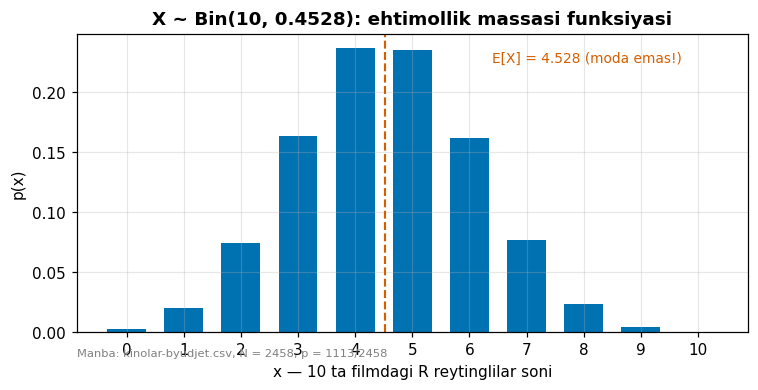

In [8]:
# --- 5-qadam: pmf ni koʻrsatish ----------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(x, p_x, width=0.68, color=oiBlue)
ax.axvline(10 * p, color=oiVerm, linestyle="--", linewidth=1.4)
ax.text(6.4, 0.225, "E[X] = 4.528 (moda emas!)", color=oiVerm, fontsize=9)
ax.set_xticks(x)
ax.set_xlabel("x — 10 ta filmdagi R reytinglilar soni")
ax.set_ylabel("p(x)")
ax.set_title("X ~ Bin(10, 0.4528): ehtimollik massasi funksiyasi",
             fontweight="bold")
fig.suptitle("")
ax.text(0, -0.055, "Manba: kinolar-byudjet.csv, N = 2458, p = 1113/2458",
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

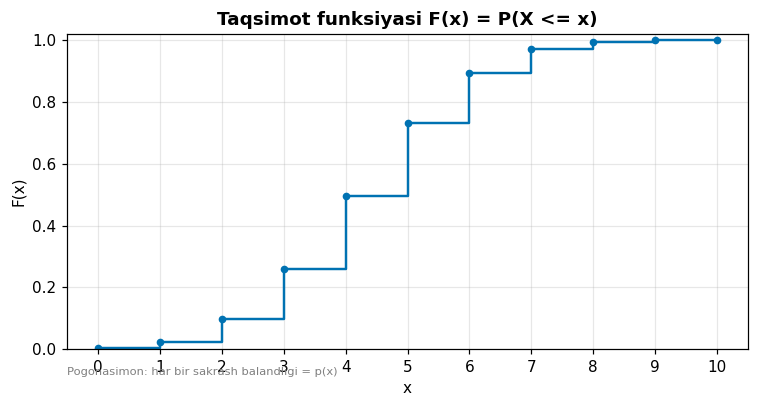

In [9]:
# --- 6-qadam: taqsimot funksiyasi — pogʻonasimon -----------------------
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.step(x, F_x, where="post", color=oiBlue, linewidth=1.6)
ax.plot(x, F_x, "o", color=oiBlue, markersize=4)
ax.set_xticks(x); ax.set_ylim(0, 1.02)
ax.set_xlabel("x"); ax.set_ylabel("F(x)")
ax.set_title("Taqsimot funksiyasi F(x) = P(X <= x)", fontweight="bold")
ax.text(0, -0.055, "Pogonasimon: har bir sakrash balandligi = p(x)",
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

### Natija (kutilayotgan)

```
maks |qoʻlda - binom.pmf| < 1e-12 : True
amaliy jihatdan tengmi           : True

(1) barcha p(x) >= 0  : True
(2) yigʻindi          : 1.000000000000
    |yigʻindi-1| < 1e-12: True
    mashina aniqligi  : 2.220e-16

  x       p(x)       F(x)     x p(x)   x^2 p(x)
  0   0.002407   0.002407   0.000000   0.000000
  1   0.019915   0.022321   0.019915   0.019915
  2   0.074159   0.096480   0.148317   0.296635
  3   0.163645   0.260126   0.490936   1.472809
  4   0.236982   0.497107   0.947927   3.791708
  5   0.235326   0.732433   1.176628   5.883138
  6   0.162278   0.894711   0.973670   5.842021
  7   0.076735   0.971447   0.537147   3.760032
  8   0.023812   0.995259   0.190498   1.523981
  9   0.004379   0.999638   0.039410   0.354687
 10   0.000362   1.000000   0.003624   0.036235

F kamaymaydimi           : True
F(10)                    : 1.000000000000
sakrash balandligi = p(x): True

P(X <  4) = F(3) = 0.260126
P(X <= 4) = F(4) = 0.497107
farq      = p(4) = 0.236982
farq aynan p(4) gami: True

P(X >= 7) = 1 - F(6) = 0.105289
P(X <= 3) = F(3)     = 0.260126
moda (eng ehtimolli x) = 4,  p = 0.236982
```

### Talqin — daftaringizga yozing

**T1.1** Yigʻindi aynan $1$ emas: farq $10^{-16}$ tartibida. Bu **xatomi**?
Javobingizda «suzuvchi nuqtali arifmetika» va «yaxlitlash» soʻzlarini
ishlating va farqning tartibini mashina aniqligi bilan solishtiring.

**T1.2** $p(x)$ ni ikki boʻlakdan yigʻdik: `comb(n, x)` va
$p^x(1-p)^{n-x}$. Har bir boʻlak *qaysi* statistik gʻoyadan keladi? Agar
sinovlar bogʻliq boʻlsa, qaysi boʻlak buziladi?

**T1.3** $\Pr(X < 4)$ va $\Pr(X \le 4)$ farqi $0{,}2370$ — bu **kichik son
emas**. Uzluksiz taqsimotlarda (5-hafta) bu farq yoʻqoladi. Nima uchun?

**T1.4** Moda $x = 4$, ammo $\E[X] = 4{,}53$. Ikkalasi ham «markaziy»
koʻrsatkich. *Qaysi savolga* moda javob beradi, *qaysi savolga* kutilma?
Har biriga bittadan aniq savol yozing.

**T1.5** $\Pr(X \ge 7) = 0{,}1053$. Kinoprokat menejeri: «Demak har oʻnta
filmdan yettitasi R reyting olishi *deyarli mumkin emas*». Bu jumlani
baholang: $10{,}5\,\%$ «deyarli mumkin emas»mi?

### Qaror

Kinoteatr har hafta $10$ ta film namoyish etadi va R reytingli filmlarga
alohida zal ajratadi. Zalda $6$ ta seans bor. **Bir haftada zal yetishmay
qolish ehtimolini** hisoblang va menejerga tavsiya bering: zalni
kengaytirish kerakmi? Javobda $\Pr(X \ge 7)$ dan foydalaning va *bir yilda
necha marta* muammo yuz berishini baholang.

---
## 2-topshiriq. Matematik kutilma va dispersiya

**Qiyinlik: 3 (Amaliy) · Blum: Qoʻllash · 20 ball · 20 daqiqa**

### Statistik tushuncha

**Matematik kutilma** — qiymatlarning ehtimolliklar bilan **ogʻirlangan**
oʻrtachasi: $\E[X] = \sum_x x\,p(x)$.

**Dispersiya** — taʼrif boʻyicha
$\Var(X) = \E[(X-\mu)^2] = \sum_x (x-\mu)^2 p(x)$; uni yoyib chiqarsak
**hisoblash formulasi** $\Var(X) = \E[X^2] - (\E[X])^2$ hosil boʻladi.

**Chiziqlilik:** $\E[aX+b] = a\E[X] + b$ va $\Var(aX+b) = a^{2}\Var(X)$.
Ikkinchisida $b$ **butunlay yoʻqoladi**.

Binomial uchun yopiq shakl: $\E[X] = np$, $\Var(X) = np(1-p)$. Bugun
**ikkala yoʻlni ham** hisoblab, ular *aynan* mos kelishini koʻrsatamiz.

### Maʼlumot

1-topshiriqdagi taqsimot (11 qator) va qoʻlda hisoblash uchun kichik
faraziy misol.

In [10]:
# --- 1-qadam: yigʻindi boʻyicha E[X] va E[X^2] -------------------------
EX  = float((x * p_x).sum())
EX2 = float((x ** 2 * p_x).sum())
VarX_hisob = EX2 - EX ** 2                    # hisoblash formulasi
VarX_tarif = float(((x - EX) ** 2 * p_x).sum())  # TAʼRIF boʻyicha

print("E[X]  = sum x p(x)      = %.6f" % EX)
print("E[X]  = n p             = %.6f" % (n * p))
print("mos      :", bool(abs(EX - n * p) < 1e-12))
print()

print("E[X^2] = sum x^2 p(x)   = %.6f" % EX2)
print("Var(X) = E[X^2]-(E X)^2 = %.6f" % VarX_hisob)
print("Var(X) = taʼrif boʻyicha= %.6f" % VarX_tarif)
print("Var(X) = n p (1-p)      = %.6f" % (n * p * (1 - p)))
print("uchalasi mos:", bool(abs(VarX_hisob - VarX_tarif) < 1e-10 and
                            abs(VarX_hisob - n * p * (1 - p)) < 1e-10))
print("SD(X) = %.6f" % sqrt(VarX_hisob))

E[X]  = sum x p(x)      = 4.528072
E[X]  = n p             = 4.528072
mos      : True

E[X^2] = sum x^2 p(x)   = 22.981161
Var(X) = E[X^2]-(E X)^2 = 2.477728
Var(X) = taʼrif boʻyicha= 2.477728
Var(X) = n p (1-p)      = 2.477728
uchalasi mos: True
SD(X) = 1.574080


In [11]:
# --- 2-qadam: qoʻlda hisoblash misoli (FARAZIY taqsimot) ----------------
# Maʼruzadagi misol: X = 0,1,2,3 ehtimolliklari 0.10, 0.35, 0.40, 0.15.
# Bu maʼlumotdan olinmagan — oʻquv maqsadida tuzilgan taqsimot.
hx = np.arange(0, 4, dtype=float)
hp = np.array([0.10, 0.35, 0.40, 0.15])
assert abs(hp.sum() - 1) < 1e-12          # SHART TEKSHIRUVI

hE  = float((hx * hp).sum())
hE2 = float((hx ** 2 * hp).sum())
hV  = hE2 - hE ** 2

print("E[X]   = %.4f" % hE)
print("E[X^2] = %.4f" % hE2)
print("Var(X) = %.4f - %.4f^2 = %.4f" % (hE2, hE, hV))
print("taʼrif boʻyicha        = %.4f" % ((hx - hE) ** 2 * hp).sum())
print("SD(X)  = %.4f" % sqrt(hV))

E[X]   = 1.6000
E[X^2] = 3.3000
Var(X) = 3.3000 - 1.6000^2 = 0.7400
taʼrif boʻyicha        = 0.7400
SD(X)  = 0.8602


In [12]:
# --- 3-qadam: CHIZIQLILIKNI sonli tekshirish ---------------------------
# Y = 3X + 2 ning taqsimotini OSHKORA quramiz va E, Var ni QAYTA
# hisoblaymiz. Formula toʻgʻri boʻlsa, natijalar aynan mos keladi.
a, b = 3, 2
hy  = a * hx + b            # yangi qiymatlar, ehtimolliklar OʻZGARMAYDI
hEy = float((hy * hp).sum())
hVy = float((hy ** 2 * hp).sum()) - hEy ** 2

print("E[3X+2]   oshkora = %.4f   formula = %.4f" % (hEy, a * hE + b))
print("Var(3X+2) oshkora = %.4f   formula = %.4f" % (hVy, a ** 2 * hV))
print("mos:", bool(abs(hEy - (a * hE + b)) < 1e-12 and
                   abs(hVy - a ** 2 * hV) < 1e-12))
print()

# Faqat SILJISH: b oʻzgaradi, a = 1. Dispersiya OʻZGARMASLIGI kerak.
hz = hx + 100
print("E[X+100]   = %.4f  (100 ga surildi)" % (hz * hp).sum())
print("Var(X+100) = %.4f  (OʻZGARMADI: %.4f)"
      % (float((hz ** 2 * hp).sum()) - float((hz * hp).sum()) ** 2, hV))

E[3X+2]   oshkora = 6.8000   formula = 6.8000
Var(3X+2) oshkora = 6.6600   formula = 6.6600
mos: True

E[X+100]   = 101.6000  (100 ga surildi)
Var(X+100) = 0.7400  (OʻZGARMADI: 0.7400)


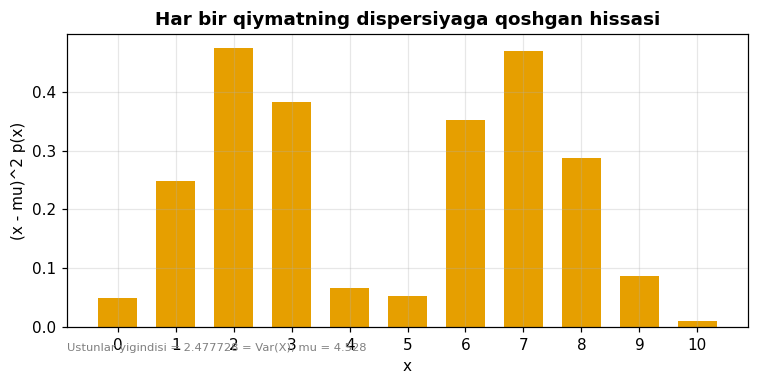

In [13]:
# --- 4-qadam: dispersiya nimani oʻlchaydi ------------------------------
# Har bir x uchun (x - mu)^2 p(x) hissasini chizamiz: dispersiya —
# aynan shu ustunlarning yigʻindisi.
hissa = (x - EX) ** 2 * p_x
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(x, hissa, width=0.68, color=oiOrange)
ax.set_xticks(x)
ax.set_xlabel("x"); ax.set_ylabel("(x - mu)^2 p(x)")
ax.set_title("Har bir qiymatning dispersiyaga qoshgan hissasi",
             fontweight="bold")
ax.text(0, -0.055,
        "Ustunlar yigindisi = %.6f = Var(X); mu = 4.528" % hissa.sum(),
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

### Natija (kutilayotgan)

```
E[X]  = sum x p(x)      = 4.528072
E[X]  = n p             = 4.528072
mos      : True

E[X^2] = sum x^2 p(x)   = 22.981161
Var(X) = E[X^2]-(E X)^2 = 2.477728
Var(X) = taʼrif boʻyicha= 2.477728
Var(X) = n p (1-p)      = 2.477728
uchalasi mos: True
SD(X) = 1.574080

E[X]   = 1.6000
E[X^2] = 3.3000
Var(X) = 3.3000 - 1.6000^2 = 0.7400
taʼrif boʻyicha        = 0.7400
SD(X)  = 0.8602

E[3X+2]   oshkora = 6.8000   formula = 6.8000
Var(3X+2) oshkora = 6.6600   formula = 6.6600
mos: True

E[X+100]   = 101.6000  (100 ga surildi)
Var(X+100) = 0.7400  (OʻZGARMADI: 0.7400)
```

### Talqin — daftaringizga yozing

**T2.1** $\E[X] = 4{,}528$ — ammo $X$ hech qachon $4{,}528$ ga teng
boʻlmaydi (u butun son). Kutilmaning **toʻgʻri talqini**ni bir jumlada
yozing. Qaysi qonun bunga asos boʻladi?

**T2.2** Dispersiyani ikki yoʻl bilan hisobladik va aynan bir xil son
chiqdi. Bu **tasodifmi**? $\Var(X) = \E[X^2] - (\E[X])^2$ ni taʼrifdan uch
qatorda keltirib chiqaring.

**T2.3** $\Var(X + 100) = \Var(X)$. Buni *soʻz bilan* tushuntiring. Endi
$\Var(3X) = 9\Var(X)$ ni ham shunday tushuntiring — nima uchun $3$ emas, $9$?

**T2.4** `assert abs(hp.sum() - 1) < 1e-12` qatori nima uchun kodda
turibdi? Agar u boʻlmasa va ehtimolliklar yigʻindisi $0{,}98$ boʻlsa,
$\E[X]$ qanday xato beradi — **oshadimi yoki kamayadimi**? Sonli misol
keltiring.

**T2.5** Dispersiya hissalari grafigida $x = 0$ va $x = 10$ ning hissasi
kichik, garchi ular oʻrtachadan eng uzoq boʻlsa ham. Nima uchun? Bu bizga
**chetlashgan kuzatuvlar** haqida nima deydi?

### Qaror

Kinoteatr R reytingli har bir film uchun qoʻshimcha $3$ mln soʻm litsenziya
toʻlaydi va haftalik $2$ mln soʻm doimiy xarajati bor. Haftalik xarajat
$C = 3X + 2$ (mln soʻm). $\E[C]$ va $\SD(C)$ ni hisoblang va moliya
boʻlimiga **byudjet chegarasi** taklif qiling: $\E[C] + 2\,\SD(C)$ qancha?
Bu chegara qanchalik tez-tez oshib ketadi?

---
## 3-topshiriq. Takroriy tanlash va cheklangan toʻplam tuzatmasi

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 25 ball · 25 daqiqa**

### Statistik tushuncha

Binomial modelning shartlari — **BINS**: ikkita natija; sinovlar
**bogʻliqsiz**; sinovlar soni $n$ **belgilangan**; $p$ **oʻzgarmas**.

Katalogdan **qaytarishsiz** tanlaganda **I** va **S** shartlari buziladi:
birinchi film R chiqsa, ikkinchisining R boʻlish ehtimoli $1112/2457$ ga
tushadi. Toʻgʻri model — **gipergeometrik**:
$$\Var(X) = n\,p(1-p)\cdot\underbrace{\frac{N-n}{N-1}}_{\text{cheklangan toʻplam tuzatmasi}}.$$

**Nima uchun yana MINSTD?** R ning `set.seed(2026)` va Pythonning
`default_rng(2026)` buyruqlari *turli* sonlar beradi. Shu sababli ikkala
daftar ham **MINSTD** (Lehmer) generatorini oʻzi yozadi:
$$x_{k+1} = (48\,271\,x_k) \bmod 2\,147\,483\,647,\qquad
u_k = x_k / 2\,147\,483\,647 .$$
Toʻliq izoh — 2-hafta laboratoriyasining 5-topshirigʻida.

> **Diqqat.** Maʼruza slaydidagi simulyatsiya sonlari ($\bar{x} = 4{,}5335$,
> $s^2 = 2{,}4718$) Pythonning `default_rng(2026)` generatoridan va
> $200\,000$ tanlanmadan olingan. Laboratoriyada MINSTD va $50\,000$
> tanlanma ishlatiladi — **ikkalasi ham toʻgʻri**.

### Maʼlumot

Haqiqiy $2\,458$ ta filmning roʻyxati (`R_bayroq` massivi). Har bir takrorda
undan **qaytarishsiz** $10$ ta tanlanadi.

In [14]:
# --- 1-qadam: MINSTD generatori (2-haftadan oʻzgarishsiz) --------------
class Minstd:
    "Lehmer generatori: x <- (48271 x) mod 2147483647."

    def __init__(self, urugh):
        self.m = 2147483647
        self.a = 48271
        x = urugh % self.m
        self.x = 1 if x == 0 else x

    def __call__(self, k):
        u = np.empty(k)
        x, a, m = self.x, self.a, self.m
        for i in range(k):
            x = (a * x) % m          # butun sonli arifmetika — aniq
            u[i] = x / m
        self.x = x
        return u


# Nazorat qiymatlari — R daftaridagi sonlar bilan SOLISHTIRING.
for i, v in enumerate(Minstd(2026)(5), start=1):
    print("u[%d] = %.10f" % (i, v))

u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903


In [15]:
# --- 2-qadam: QAYTARISHSIZ tanlash funksiyasi --------------------------
# Rad etish (rejection) usuli: indeks tanlanadi; agar u allaqachon
# olingan boʻlsa, TASHLANADI va yangisi olinadi. Ikkala tilda AYNAN
# shu tartib bajarilgani uchun natija bit darajasida bir xil chiqadi.
def tanla(u, ptr, Npop, n_ta, bayroq):
    olingan = []
    while len(olingan) < n_ta:
        j = int(u[ptr] * Npop)          # 0, 1, ..., Npop-1
        ptr += 1
        if j not in olingan:
            olingan.append(j)
    return int(sum(bayroq[j] for j in olingan)), ptr

In [16]:
# --- 3-qadam: 50 000 ta takror -----------------------------------------
TAKROR = 50000
BYUDJET = 20          # bitta tanlanmaga ajratilgan tasodifiy sonlar

g = Minstd(2026)
u = g(TAKROR * BYUDJET)

ptr = 0
Xsim = np.empty(TAKROR, dtype=int)
for i in range(TAKROR):
    Xsim[i], ptr = tanla(u, ptr, N_pop, n, R_bayroq)
assert ptr <= len(u)                    # NAZORAT: oqim yetdimi?

print("ishlatilgan tasodifiy son  : %d  (tanlanmaga %.5f)"
      % (ptr, ptr / TAKROR))
print("simulyatsiya oʻrtachasi    : %.5f" % Xsim.mean())
print("simulyatsiya dispersiyasi  : %.5f" % Xsim.var(ddof=1))

ishlatilgan tasodifiy son  : 500962  (tanlanmaga 10.01924)
simulyatsiya oʻrtachasi    : 4.52714
simulyatsiya dispersiyasi  : 2.46211


In [17]:
# --- 4-qadam: uchta nazariy qiymat bilan taqqoslash ---------------------
Var_bin = n * p * (1 - p)
FPC = (N_pop - n) / (N_pop - 1)
Var_fpc = Var_bin * FPC

# Monte-Karlo xatosi: simulyatsiyaning OʻZI qanchalik aniq?
mu4 = n * p * (1 - p) * (1 + 3 * (n - 2) * p * (1 - p))   # 4-markaziy moment
SE_s2 = sqrt((mu4 - Var_bin ** 2) / TAKROR)
SE_mean = sqrt(Var_bin / TAKROR)

print("nazariy E[X] = n p             : %.5f" % (n * p))
print("simulyatsiya oʻrtachasi        : %.5f   (SE = %.5f)"
      % (Xsim.mean(), SE_mean))
print("farq / SE                      : %.2f\n"
      % ((Xsim.mean() - n * p) / SE_mean))

print("binomial dispersiya n p (1-p)  : %.5f" % Var_bin)
print("cheklangan toʻplam tuzatmasi   : %.6f  (%.2f %%)"
      % (FPC, 100 * (1 - FPC)))
print("tuzatilgan (gipergeometrik)    : %.5f" % Var_fpc)
print("simulyatsiya dispersiyasi      : %.5f   (SE = %.5f)"
      % (Xsim.var(ddof=1), SE_s2))
print("  |sim - binomial| / SE        : %.2f"
      % (abs(Xsim.var(ddof=1) - Var_bin) / SE_s2))
print("  |sim - tuzatilgan| / SE      : %.2f"
      % (abs(Xsim.var(ddof=1) - Var_fpc) / SE_s2))
print("\nXULOSA: tuzatma (0.37 %) simulyatsiyaning OʻZ xatosidan kichik.")
print("Demak bu tajriba ikki modelni AJRATA OLMAYDI — buni tan olish")
print("kerak, «binomial tasdiqlandi» deb yozish emas.")

nazariy E[X] = n p             : 4.52807
simulyatsiya oʻrtachasi        : 4.52714   (SE = 0.00704)
farq / SE                      : -0.13

binomial dispersiya n p (1-p)  : 2.47773
cheklangan toʻplam tuzatmasi   : 0.996337  (0.37 %)
tuzatilgan (gipergeometrik)    : 2.46865
simulyatsiya dispersiyasi      : 2.46211   (SE = 0.01488)
  |sim - binomial| / SE        : 1.05
  |sim - tuzatilgan| / SE      : 0.44

XULOSA: tuzatma (0.37 %) simulyatsiyaning OʻZ xatosidan kichik.
Demak bu tajriba ikki modelni AJRATA OLMAYDI — buni tan olish
kerak, «binomial tasdiqlandi» deb yozish emas.


In [18]:
# --- 5-qadam: empirik va nazariy taqsimotni yonma-yon qoʻyish ----------
kuzatilgan = np.bincount(Xsim, minlength=n + 1)
empirik = kuzatilgan / TAKROR
print("%3s %11s %10s %10s %11s"
      % ("x", "kuzatilgan", "empirik", "binomial", "kutilgan"))
for i in range(len(x)):
    print("%3d %11d %10.5f %10.6f %11.2f"
          % (x[i], kuzatilgan[i], empirik[i], p_x[i], TAKROR * p_x[i]))
print("maks |empirik - p(x)| = %.5f" % np.abs(empirik - p_x).max())

  x  kuzatilgan    empirik   binomial    kutilgan
  0         104    0.00208   0.002407      120.33
  1        1030    0.02060   0.019915      995.74
  2        3710    0.07420   0.074159     3707.94
  3        8136    0.16272   0.163645     8182.27
  4       11774    0.23548   0.236982    11849.09
  5       11885    0.23770   0.235326    11766.28
  6        8153    0.16306   0.162278     8113.92
  7        3835    0.07670   0.076735     3836.77
  8        1156    0.02312   0.023812     1190.61
  9         203    0.00406   0.004379      218.94
 10          14    0.00028   0.000362       18.12
maks |empirik - p(x)| = 0.00237


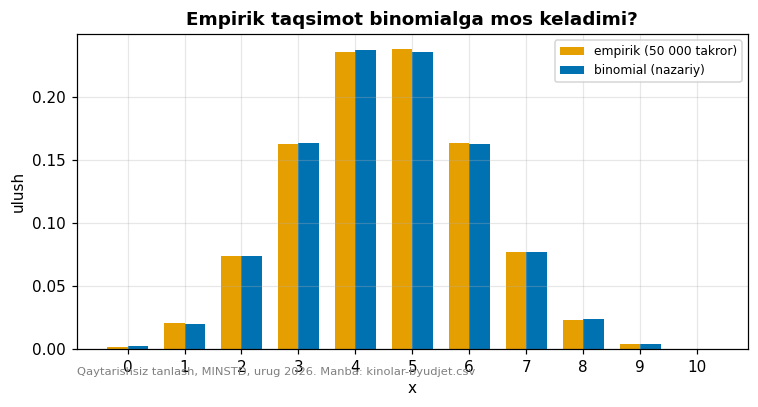

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.8))
w = 0.36
ax.bar(x - w / 2, empirik, width=w, color=oiOrange,
       label="empirik (50 000 takror)")
ax.bar(x + w / 2, p_x, width=w, color=oiBlue, label="binomial (nazariy)")
ax.set_xticks(x); ax.set_xlabel("x"); ax.set_ylabel("ulush")
ax.set_title("Empirik taqsimot binomialga mos keladimi?", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.text(0, -0.055,
        "Qaytarishsiz tanlash, MINSTD, urug 2026. Manba: kinolar-byudjet.csv",
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

In [20]:
# --- 6-qadam: TUZATMA QACHON AHAMIYATLI BOʻLADI ------------------------
# Yuqorida n/N = 10/2458 = 0.4 % — tuzatma sezilmadi. Endi KICHIK
# populyatsiya olamiz: faqat 2018-yilda chiqqan filmlar.
kichik = kino_t[kino_t["yil"] == 2018].reset_index(drop=True)
N_kichik = len(kichik)
R_kichik = (kichik["reyting"] == "R").to_numpy().astype(int)
p_kichik = float(R_kichik.mean())

print("2018-yil: N = %d, R reytinglilar = %d, p = %.6f"
      % (N_kichik, int(R_kichik.sum()), p_kichik))
print("n/N = %.4f  (yuqorida %.4f edi)" % (n / N_kichik, n / N_pop))

g2 = Minstd(2026)              # AYNAN oʻsha urugʻ — taqqoslash uchun
u2 = g2(TAKROR * BYUDJET)
ptr = 0
Ysim = np.empty(TAKROR, dtype=int)
for i in range(TAKROR):
    Ysim[i], ptr = tanla(u2, ptr, N_kichik, n, R_kichik)

Var_bin_k = n * p_kichik * (1 - p_kichik)
FPC_k = (N_kichik - n) / (N_kichik - 1)

print("\nsimulyatsiya oʻrtachasi   : %.5f  (nazariy n p = %.5f)"
      % (Ysim.mean(), n * p_kichik))
print("simulyatsiya dispersiyasi : %.5f" % Ysim.var(ddof=1))
print("binomial n p (1-p)        : %.5f   <- %.1f %% ORTIQCHA"
      % (Var_bin_k, 100 * (Var_bin_k / Ysim.var(ddof=1) - 1)))
print("tuzatma (N-n)/(N-1)       : %.6f" % FPC_k)
print("gipergeometrik            : %.5f   <- MOS KELADI"
      % (Var_bin_k * FPC_k))

2018-yil: N = 53, R reytinglilar = 20, p = 0.377358
n/N = 0.1887  (yuqorida 0.0041 edi)



simulyatsiya oʻrtachasi   : 3.77486  (nazariy n p = 3.77358)
simulyatsiya dispersiyasi : 1.94497
binomial n p (1-p)        : 2.34959   <- 20.8 % ORTIQCHA
tuzatma (N-n)/(N-1)       : 0.826923
gipergeometrik            : 1.94293   <- MOS KELADI


### Natija (kutilayotgan)

```
u[1] = 0.0455402984
u[2] = 0.2757419647
u[3] = 0.3403783731
u[4] = 0.4044473546
u[5] = 0.0782521903

ishlatilgan tasodifiy son  : 500962  (tanlanmaga 10.01924)
simulyatsiya oʻrtachasi    : 4.52714
simulyatsiya dispersiyasi  : 2.46211

nazariy E[X] = n p             : 4.52807
simulyatsiya oʻrtachasi        : 4.52714   (SE = 0.00704)
farq / SE                      : -0.13

binomial dispersiya n p (1-p)  : 2.47773
cheklangan toʻplam tuzatmasi   : 0.996337  (0.37 %)
tuzatilgan (gipergeometrik)    : 2.46865
simulyatsiya dispersiyasi      : 2.46211   (SE = 0.01488)
  |sim - binomial| / SE        : 1.05
  |sim - tuzatilgan| / SE      : 0.44

XULOSA: tuzatma (0.37 %) simulyatsiyaning OʻZ xatosidan kichik.
Demak bu tajriba ikki modelni AJRATA OLMAYDI — buni tan olish
kerak, «binomial tasdiqlandi» deb yozish emas.

  x  kuzatilgan    empirik   binomial    kutilgan
  0         104    0.00208   0.002407      120.33
  1        1030    0.02060   0.019915      995.74
  2        3710    0.07420   0.074159     3707.94
  3        8136    0.16272   0.163645     8182.27
  4       11774    0.23548   0.236982    11849.09
  5       11885    0.23770   0.235326    11766.28
  6        8153    0.16306   0.162278     8113.92
  7        3835    0.07670   0.076735     3836.77
  8        1156    0.02312   0.023812     1190.61
  9         203    0.00406   0.004379      218.94
 10          14    0.00028   0.000362       18.12
maks |empirik - p(x)| = 0.00237

2018-yil: N = 53, R reytinglilar = 20, p = 0.377358
n/N = 0.1887  (yuqorida 0.0041 edi)

simulyatsiya oʻrtachasi   : 3.77486  (nazariy n p = 3.77358)
simulyatsiya dispersiyasi : 1.94497
binomial n p (1-p)        : 2.34959   <- 20.8 % ORTIQCHA
tuzatma (N-n)/(N-1)       : 0.826923
gipergeometrik            : 1.94293   <- MOS KELADI
```

### Talqin — daftaringizga yozing

**T3.1** Katta populyatsiyada simulyatsiya dispersiyasi ($2{,}46211$)
binomialdan ham ($2{,}47773$), tuzatilgan qiymatdan ham ($2{,}46865$)
$1{,}05$ va $0{,}44$ SE uzoqlikda. **Bu tajriba qaysi modelni tanlashga
imkon beradi?** Javobingiz «hech qaysisini» boʻlsa — bu **kuchli** javob;
nima uchun ekanini tushuntiring.

**T3.2** Kichik populyatsiyada ($N = 53$) binomial dispersiyani
$20{,}8\,\%$ ga **oshirib** yubordi. Nima uchun binomial har doim *oshirib*
yuboradi, hech qachon kamaytirmaydi? Tuzatma formulasidan javob bering.

**T3.3** Amaliy qoida: $n < 0{,}05N$ boʻlsa binomial maqbul. Bizning ikki
holatda $n/N$ qiymatlari $0{,}0041$ va $0{,}1887$. Qoida ikkala holatni ham
toʻgʻri tasnifladimi? Qoidaning **oʻzboshimchalik** elementi qayerda?

**T3.4** Oʻrtacha ikkala holatda ham *aynan* toʻgʻri chiqdi. Nima uchun
qaytarishsiz tanlash **kutilmani buzmaydi**? (Maslahat: har bir alohida
film uchun $\Pr(\text{R}) = p$ oʻzgarmaydi; buziladigan narsa —
*bogʻliqsizlik*.)

**T3.5** `assert ptr <= len(u)` va `if j not in olingan` qatorlari nima
uchun kerak? Ikkinchisi olib tashlansa, simulyatsiya *qanday* modelni
hisoblab qoʻyadi va natija qaysi tomonga siljiydi?

**T3.6** Bir tildagi natijangiz boshqa tildagi talabaning natijasi bilan
**aynan** mos tushishi kerak. Bu mos tushish nimani **isbotlaydi** va
nimani **isbotlamaydi**?

### Qaror

Marketing agentligi $2\,458$ ta film katalogidan $10$ tasini tasodifiy
tanlab tadqiqot oʻtkazmoqchi; xarajat tejash uchun ular faqat $60$ ta
filmdan iborat qisqa roʻyxatdan tanlashni taklif qilmoqda. Statistik
nuqtayi nazardan bu nimani oʻzgartiradi? Dispersiyaning oʻzgarishini
**hisoblang** va agentlikka yozma tavsiya bering.

---
## 4-topshiriq. Dispersiya/oʻrtacha nisbati: Puasson qayerda mos keladi

**Qiyinlik: 5 (Ilgʻor) · Blum: Baholash · 25 ball · 25 daqiqa**

### Statistik tushuncha

**Puasson taqsimoti**:
$\Pr(X = x) = e^{-\lambda}\lambda^{x}/x!$, $x = 0,1,2,\dots$, va uning
**imzo xossasi** $\E[X] = \Var(X) = \lambda$.

Bu — *tekshiriladigan* shart: maʼlumotda $s^2/\bar{x}$ nisbati $1$ atrofida
boʻlishi kerak.

**Ammo «atrofida» qancha?** Agar maʼlumot chindan ham Puasson boʻlsa, $n$ ta
kuzatuv uchun nisbatning standart ogʻishi taxminan
$\SE(s^2/\bar{x}) \approx \sqrt{2/(n-1)}$. $n = 19$ da bu $0{,}333$ — yaʼni
$0{,}33$ dan $1{,}67$ gacha boʻlgan har qanday nisbat Puasson bilan
**muvofiq**. Nisbatni *chegarasiz* oʻqish — bugungi eng koʻp uchraydigan
xato.

### Maʼlumot

Bitta fayl, oltita **turli sanoq oʻzgaruvchisi**. Hammasi butun son,
hammasi manfiy emas, hammasi «sanoq». Puasson ularning faqat bir qismiga
mos keladi.

In [21]:
# --- 1-qadam: oltita sanoq seriyasini qurish ---------------------------
yillar = np.arange(2000, 2019)

def yil_sanogi(shart):
    shart = pd.Series(shart).fillna(False).to_numpy().astype(bool)
    t = kino_t.loc[shart].groupby("yil").size().reindex(yillar, fill_value=0)
    return t.to_numpy().astype(float)

seriyalar = {
    "Horror / yil":                   yil_sanogi(kino_t["janr"] == "Horror"),
    "Action / yil":                   yil_sanogi(kino_t["janr"] == "Action"),
    "Jahon daromadi > 500 mln / yil": yil_sanogi(kino_t["jahon_daromadi"] > 5e8),
    "G reyting / yil":                yil_sanogi(kino_t["reyting"] == "G"),
    "Barcha filmlar / yil":           yil_sanogi(np.ones(len(kino_t), bool)),
    "Filmlar / distribyutor":
        kino_t.groupby("distribyutor").size().to_numpy().astype(float),
}

for nm, s in seriyalar.items():
    print("%-32s n=%3d  %s"
          % (nm, len(s), " ".join(str(int(t)) for t in s[:19])))

Horror / yil                     n= 19  7 8 8 11 8 16 16 16 12 12 14 13 13 9 7 9 11 12 6
Action / yil                     n= 19  19 18 21 21 16 27 22 16 19 13 19 22 13 24 19 18 16 19 16
Jahon daromadi > 500 mln / yil   n= 19  1 1 1 2 5 3 3 5 3 2 4 6 4 5 7 6 6 6 5
G reyting / yil                  n= 19  7 5 6 2 1 5 5 2 5 3 1 4 1 0 1 1 0 0 0
Barcha filmlar / yil             n= 19  131 128 143 132 132 149 168 137 150 123 148 157 115 113 129 132 122 96 53
Filmlar / distribyutor           n=168  201 1 16 3 1 1 1 7 1 14 3 13 2 1 1 3 1 1 4


In [22]:
# --- 2-qadam: nisbat va uning NOANIQLIGI --------------------------------
print("%-31s %4s %9s %10s %9s %6s %9s  %s"
      % ("seriya", "n", "xbar", "s2", "nisbat", "SE", "z", "xulosa"))
for nm, s in seriyalar.items():
    nn = len(s); m = s.mean(); v = s.var(ddof=1)
    se = sqrt(2 / (nn - 1))          # Puasson boʻlganda nisbatning SE si
    z = (v / m - 1) / se
    xulosa = ("Puasson MUVOFIQ" if abs(z) < 2 else
              ("haddan tarqoq" if v / m > 1 else "juda tekis"))
    print("%-31s %4d %9.4f %10.4f %9.4f %6.4f %9.2f  %s"
          % (nm, nn, m, v, v / m, se, z, xulosa))

seriya                             n      xbar         s2    nisbat     SE         z  xulosa
Horror / yil                      19   10.9474    10.3860    0.9487 0.3333     -0.15  Puasson MUVOFIQ
Action / yil                      19   18.8421    12.4737    0.6620 0.3333     -1.01  Puasson MUVOFIQ
Jahon daromadi > 500 mln / yil    19    3.9474     3.7193    0.9422 0.3333     -0.17  Puasson MUVOFIQ
G reyting / yil                   19    2.5789     5.3684    2.0816 0.3333      3.24  haddan tarqoq
Barcha filmlar / yil              19  129.3684   622.1345    4.8090 0.3333     11.43  haddan tarqoq
Filmlar / distribyutor           168   14.5119  1672.7903  115.2702 0.1094   1044.18  haddan tarqoq


In [23]:
# --- 3-qadam: eng mos seriyani BATAFSIL tekshirish ----------------------
# Nisbat 1 ga yaqin boʻlishi — zaruriy shart, YETARLI shart emas.
h = seriyalar["Horror / yil"]
lam_h = h.mean()
print("lambda^ = xbar = %.4f ; s2 = %.4f ; nisbat = %.4f\n"
      % (lam_h, h.var(ddof=1), h.var(ddof=1) / lam_h))

guruh = {"<= 7": range(0, 8), "8-9": range(8, 10), "10-11": range(10, 12),
         "12-13": range(12, 14), ">= 14": range(14, 41)}
print("%-7s %11s %9s" % ("guruh", "kuzatilgan", "kutilgan"))
jami_k = 0; jami_e = 0.0
for nm, kk in guruh.items():
    obs = int(np.isin(h, list(kk)).sum())
    exp_ = len(h) * float(sum(poisson.pmf(k, lam_h) for k in kk))
    jami_k += obs; jami_e += exp_
    print("%-7s %11d %9.2f" % (nm, obs, exp_))
print("%-7s %11d %9.2f" % ("JAMI", jami_k, jami_e))

lambda^ = xbar = 10.9474 ; s2 = 10.3860 ; nisbat = 0.9487

guruh    kuzatilgan  kutilgan
<= 7              3      2.79
8-9               5      3.79
10-11             2      4.55
12-13             5      3.81
>= 14             4      4.06
JAMI             19     19.00


In [24]:
# --- 4-qadam: NIMA UCHUN G reyting seriyasi mos kelmaydi -----------------
# Puassonning sharti: oʻrtacha tezlik OʻZGARMAS. Uni tekshiramiz.
g_ser = seriyalar["G reyting / yil"]
h_ser = seriyalar["Horror / yil"]
print("G reyting : birinchi 6 yil oʻrtacha = %.4f ; oxirgi 6 yil = %.4f"
      % (g_ser[:6].mean(), g_ser[13:19].mean()))
print("Horror    : birinchi 6 yil oʻrtacha = %.4f ; oxirgi 6 yil = %.4f"
      % (h_ser[:6].mean(), h_ser[13:19].mean()))
print("\nG reyting seriyasida tezlik 13 barobar tushgan: «oʻzgarmas")
print("tezlik» sharti buzilgan. Sanoq boʻlishi Puassonni oqlamaydi.")

G reyting : birinchi 6 yil oʻrtacha = 4.3333 ; oxirgi 6 yil = 0.3333
Horror    : birinchi 6 yil oʻrtacha = 9.6667 ; oxirgi 6 yil = 9.0000

G reyting seriyasida tezlik 13 barobar tushgan: «oʻzgarmas
tezlik» sharti buzilgan. Sanoq boʻlishi Puassonni oqlamaydi.


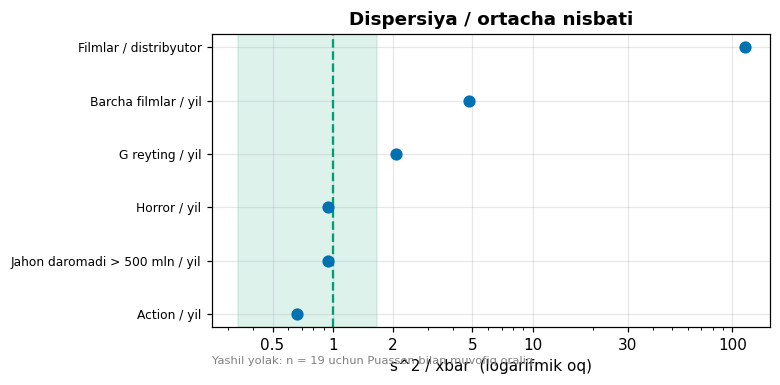

In [25]:
nomlar = list(seriyalar.keys())
nisbatlar = np.array([s.var(ddof=1) / s.mean() for s in seriyalar.values()])
tartib = np.argsort(nisbatlar)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.axvspan(1 - 2 * 0.333, 1 + 2 * 0.333, color=oiGreen, alpha=0.13)
ax.axvline(1, color=oiGreen, linestyle="--")
ax.plot(nisbatlar[tartib], np.arange(len(tartib)), "o",
        color=oiBlue, markersize=7)
ax.set_yticks(np.arange(len(tartib)))
ax.set_yticklabels([nomlar[i] for i in tartib], fontsize=8)
ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 5, 10, 30, 100])
ax.set_xticklabels(["0.5", "1", "2", "5", "10", "30", "100"])
ax.set_xlabel("s^2 / xbar  (logarifmik oq)")
ax.set_title("Dispersiya / ortacha nisbati", fontweight="bold")
ax.text(0, -0.10, "Yashil yolak: n = 19 uchun Puasson bilan muvofiq oraliq",
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

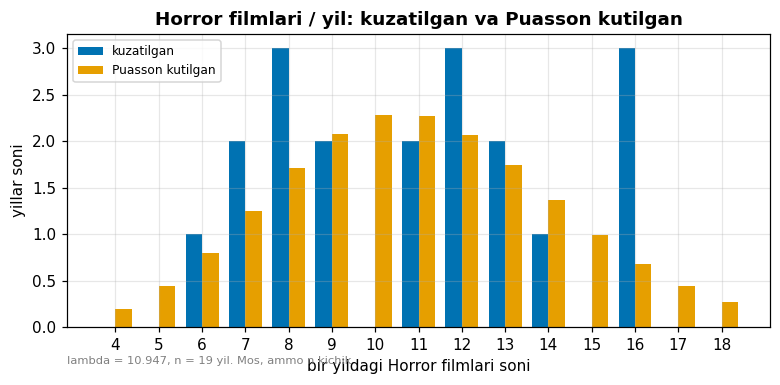

In [26]:
kk = np.arange(4, 19)
obs = np.array([int((h == k).sum()) for k in kk], dtype=float)
exp_ = len(h) * poisson.pmf(kk, lam_h)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
w = 0.38
ax.bar(kk - w / 2, obs, width=w, color=oiBlue, label="kuzatilgan")
ax.bar(kk + w / 2, exp_, width=w, color=oiOrange, label="Puasson kutilgan")
ax.set_xticks(kk)
ax.set_xlabel("bir yildagi Horror filmlari soni")
ax.set_ylabel("yillar soni")
ax.set_title("Horror filmlari / yil: kuzatilgan va Puasson kutilgan",
             fontweight="bold")
ax.legend(fontsize=8)
ax.text(0, -0.10, "lambda = 10.947, n = 19 yil. Mos, ammo n kichik",
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

### Natija (kutilayotgan)

```
Horror / yil                     n= 19  7 8 8 11 8 16 16 16 12 12 14 13 13 9 7 9 11 12 6
Action / yil                     n= 19  19 18 21 21 16 27 22 16 19 13 19 22 13 24 19 18 16 19 16
Jahon daromadi > 500 mln / yil   n= 19  1 1 1 2 5 3 3 5 3 2 4 6 4 5 7 6 6 6 5
G reyting / yil                  n= 19  7 5 6 2 1 5 5 2 5 3 1 4 1 0 1 1 0 0 0
Barcha filmlar / yil             n= 19  131 128 143 132 132 149 168 137 150 123 148 157 115 113 129 132 122 96 53
Filmlar / distribyutor           n=168  201 1 16 3 1 1 1 7 1 14 3 13 2 1 1 3 1 1 4

seriya                             n      xbar         s2    nisbat     SE         z  xulosa
Horror / yil                      19   10.9474    10.3860    0.9487 0.3333     -0.15  Puasson MUVOFIQ
Action / yil                      19   18.8421    12.4737    0.6620 0.3333     -1.01  Puasson MUVOFIQ
Jahon daromadi > 500 mln / yil    19    3.9474     3.7193    0.9422 0.3333     -0.17  Puasson MUVOFIQ
G reyting / yil                   19    2.5789     5.3684    2.0816 0.3333      3.24  haddan tarqoq
Barcha filmlar / yil              19  129.3684   622.1345    4.8090 0.3333     11.43  haddan tarqoq
Filmlar / distribyutor           168   14.5119  1672.7903  115.2702 0.1094   1044.18  haddan tarqoq

lambda^ = xbar = 10.9474 ; s2 = 10.3860 ; nisbat = 0.9487

guruh    kuzatilgan  kutilgan
<= 7              3      2.79
8-9               5      3.79
10-11             2      4.55
12-13             5      3.81
>= 14             4      4.06
JAMI             19     19.00

G reyting : birinchi 6 yil oʻrtacha = 4.3333 ; oxirgi 6 yil = 0.3333
Horror    : birinchi 6 yil oʻrtacha = 9.6667 ; oxirgi 6 yil = 9.0000

G reyting seriyasida tezlik 13 barobar tushgan: «oʻzgarmas
tezlik» sharti buzilgan. Sanoq boʻlishi Puassonni oqlamaydi.
```

### Talqin — daftaringizga yozing

**T4.1** Oltita seriyaning hammasi sanoq. Uchtasi Puassonga mos, uchtasi
mos emas. **Farq qayerda?** Har bir mos kelmagan seriya uchun buzilgan
shartni *nomlang* (bogʻliqsizlik, oʻzgarmas tezlik, yoki ikkalasi).

**T4.2** «Filmlar / distribyutor» nisbati $115$. Bu shunchaki «katta» emas
— $z = 1044$. Nima uchun distribyutorlar boʻyicha sanoq **hech qachon**
Puasson boʻla olmaydi? (Maslahat: bitta studiya $264$ ta film chiqargan,
oʻnlab studiya bittadan.)

**T4.3** «Action / yil» nisbati $0{,}662$ — $1$ dan **kichik**. Bu qanday
jarayonni bildiradi? Kinostudiyalar yiliga chiqariladigan film sonini
*rejalashtiradi* — bu Puassonning qaysi sharti bilan ziddiyatda?

**T4.4** $n = 19$ uchun muvofiq oraliq $[0{,}33;\ 1{,}67]$ juda keng.
Oraliqni ikki barobar toraytirish uchun $n$ nechaga yetishi kerak?
Formuladan hisoblang. Bu bizga **kichik namunalarda model tanlash** haqida
nima deydi?

**T4.5** Horror seriyasida nisbat $0{,}949$ — ajoyib. Ammo guruhlangan
jadvalda $10$–$11$ oraligʻida $2$ kuzatilgan, $4{,}55$ kutilgan. Bu
**modelni rad etish** uchun asosmi? Javobingizda $n = 19$ ning kichikligini
eslang.

**T4.6** G reyting seriyasining oʻrtachasi $13$ barobar tushdi. Agar
tahlilni faqat $2013$–$2018$ yillar uchun qilsak, nisbat qanday boʻlishi
mumkin? Hisoblang va **nima uchun bu ham «yechim» emas**ligini ayting.

### Qaror

Chaqiruv markazi rahbari: «Bizga soatiga oʻrtacha $40$ ta qoʻngʻiroq
keladi, demak Puasson modelini olamiz va $\lambda = 40$ deb xodimlarni
rejalashtiramiz». Undan **qaysi uchta savolni** soʻrar edingiz va **qanday
maʼlumot** talab qilar edingiz? Agar $s^2/\bar{x} = 3{,}5$ chiqsa, xodimlar
rejasi qaysi tomonga xato boʻladi — **kam** yoki **koʻp** xodim
rejalashtiriladi? Sabab bilan javob bering.

---
## 5-topshiriq. Puasson — binomialning limiti

**Qiyinlik: 4 (Analitik) · Blum: Tahlil · 20 ball · 20 daqiqa**

### Statistik tushuncha

$n$ katta, $p$ kichik va $np = \lambda$ oʻzgarmas boʻlganda
$\Bin(n, \lambda/n) \to \Pois(\lambda)$.

Buni **isbot** sifatida emas, **son** sifatida koʻramiz: $n$ ni oshirib
borib, ikki taqsimot orasidagi eng katta farqni oʻlchaymiz.

Amaliy foydasi ikkita: (i) $\binom{10\,000}{3}$ ni hisoblash ogʻir,
Puasson formulasi esa uch amaldan iborat; (ii) koʻp real jarayonlarda $n$
maʼlum emas — Puasson $n$ ni talab qilmaydi.

### Maʼlumot

Maʼlumot fayli yoʻq — bu **sof sonli tajriba**. $\lambda = 5$.

In [27]:
# --- 1-qadam: yaqinlashishni oʻlchash ----------------------------------
lam = 5.0
n_lar = [10, 50, 100, 1000, 10000]

print("%7s %12s %12s %12s" % ("n", "P(X=3) bin", "|farq| P3", "maks farq"))
for nn in n_lar:
    pp = lam / nn
    kk = np.arange(0, min(nn, 40) + 1)
    b = binom.pmf(kk, nn, pp)
    po = poisson.pmf(kk, lam)
    print("%7d %12.6f %12.8f %12.8f"
          % (nn, binom.pmf(3, nn, pp),
             abs(binom.pmf(3, nn, pp) - poisson.pmf(3, lam)),
             np.abs(b - po).max()))
print("%7s %12.6f" % ("Pois(5)", poisson.pmf(3, lam)))

      n   P(X=3) bin    |farq| P3    maks farq
     10     0.117188   0.02318640   0.07062638
     50     0.138565   0.00180875   0.00945723
    100     0.139576   0.00079822   0.00455046
   1000     0.140303   0.00007111   0.00044025
  10000     0.140367   0.00000703   0.00004388
Pois(5)     0.140374


In [28]:
# --- 2-qadam: amaliy qoidani sinash (n >= 20, p <= 0.05) ---------------
print("%5s %6s %8s %11s  %s" % ("n", "p", "lambda", "maks farq", "qoida"))
for pp in (0.01, 0.05, 0.10, 0.30):
    for nn in (10, 20, 50, 100):
        kk = np.arange(0, nn + 1)
        mf = np.abs(binom.pmf(kk, nn, pp) - poisson.pmf(kk, nn * pp)).max()
        qq = "qoida BAJARILDI" if (nn >= 20 and pp <= 0.05) else "-"
        print("%5d %6.2f %8.2f %11.6f  %s" % (nn, pp, nn * pp, mf, qq))

    n      p   lambda   maks farq  qoida
   10   0.01     0.10    0.000868  -
   20   0.01     0.20    0.001488  qoida BAJARILDI
   50   0.01     0.50    0.002293  qoida BAJARILDI
  100   0.01     1.00    0.001850  qoida BAJARILDI
   10   0.05     0.50    0.011859  -
   20   0.05     1.00    0.009474  qoida BAJARILDI
   50   0.05     2.50    0.006112  qoida BAJARILDI
  100   0.05     5.00    0.004550  qoida BAJARILDI
   10   0.10     1.00    0.019541  -
   20   0.10     2.00    0.014509  -
   50   0.10     5.00    0.009457  -
  100   0.10    10.00    0.006755  -
   10   0.30     3.00    0.042786  -
   20   0.30     6.00    0.031016  -
   50   0.30    15.00    0.019911  -
  100   0.30    30.00    0.014149  -


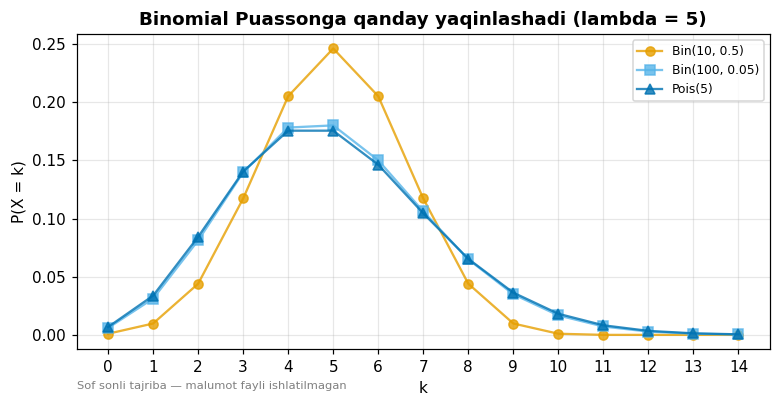

In [29]:
kk = np.arange(0, 15)
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(kk, binom.pmf(kk, 10, 0.5), "o-", color=oiOrange,
        alpha=0.8, label="Bin(10, 0.5)")
ax.plot(kk, binom.pmf(kk, 100, 0.05), "s-", color=oiSky,
        alpha=0.8, label="Bin(100, 0.05)")
ax.plot(kk, poisson.pmf(kk, 5), "^-", color=oiBlue,
        alpha=0.8, label="Pois(5)")
ax.set_xticks(kk); ax.set_xlabel("k"); ax.set_ylabel("P(X = k)")
ax.set_title("Binomial Puassonga qanday yaqinlashadi (lambda = 5)",
             fontweight="bold")
ax.legend(fontsize=8)
ax.text(0, -0.10, "Sof sonli tajriba — malumot fayli ishlatilmagan",
        transform=ax.transAxes, fontsize=7.5, color="grey", va="top")
plt.tight_layout(); plt.show()

### Natija (kutilayotgan)

```
      n   P(X=3) bin    |farq| P3    maks farq
     10     0.117188   0.02318640   0.07062638
     50     0.138565   0.00180875   0.00945723
    100     0.139576   0.00079822   0.00455046
   1000     0.140303   0.00007111   0.00044025
  10000     0.140367   0.00000703   0.00004388
Pois(5)     0.140374

    n      p   lambda   maks farq  qoida
   10   0.01     0.10    0.000868  -
   20   0.01     0.20    0.001488  qoida BAJARILDI
   50   0.01     0.50    0.002293  qoida BAJARILDI
  100   0.01     1.00    0.001850  qoida BAJARILDI
   10   0.05     0.50    0.011859  -
   20   0.05     1.00    0.009474  qoida BAJARILDI
   50   0.05     2.50    0.006112  qoida BAJARILDI
  100   0.05     5.00    0.004550  qoida BAJARILDI
   10   0.10     1.00    0.019541  -
   20   0.10     2.00    0.014509  -
   50   0.10     5.00    0.009457  -
  100   0.10    10.00    0.006755  -
   10   0.30     3.00    0.042786  -
   20   0.30     6.00    0.031016  -
   50   0.30    15.00    0.019911  -
  100   0.30    30.00    0.014149  -
```

### Talqin — daftaringizga yozing

**T5.1** Jadvalda `maks farq` $n$ oshgani sari kamayadi, ammo $p$
oʻzgarmaganda $n$ ni oshirish deyarli **yordam bermaydi** ($p = 0{,}30$ da
$0{,}0428 \to 0{,}0141$, ammo hech qachon nolga intilmaydi).
Yaqinlashishni **qaysi kattalik** boshqaradi — $n$ mi, $p$ mi, yoki
$\lambda$ mi? Jadvaldan dalil keltiring.

**T5.2** `|farq| P3` va `maks farq` ustunlarini solishtiring: $n = 10$ da
$0{,}0232$ va $0{,}0706$. Nima uchun **bitta nuqtadagi** farq butun
taqsimotdagi eng katta farqdan kichik? Modelni faqat bitta nuqtada
tekshirish nima uchun xavfli?

**T5.3** «$n \ge 20$ va $p \le 0{,}05$» qoidasi jadvalda qanday ishladi?
$n = 10$, $p = 0{,}05$ holatida farq $0{,}0119$ — qoida buzilgan, ammo farq
kichik. Qoida **haddan ortiq ehtiyotkormi**? Javobingizni asoslang.

**T5.4** 4-topshiriqda «Jahon daromadi $>500$ mln / yil» seriyasi Puassonga
mos keldi ($\bar{x} = 3{,}95$). Bu seriyani binomial sifatida ham qarash
mumkinmi? Agar ha, $n$ va $p$ nima boʻlar edi va ularni maʼlumotdan
**ajratib** olish mumkinmi?

**T5.5** Puasson $n$ ni talab qilmaydi. Bu **afzallikmi yoki kamchilikmi**?
Har biriga bittadan misol keltiring.

### Qaror

Bank filialiga bir soatda oʻrtacha $2$ ta yirik kredit arizasi keladi.
Filial menejeri: «Kunlik $8$ soatda $16$ ta ariza kutamiz; $25$ tadan koʻp
kelish ehtimoli qanchalik?» Puasson bilan hisoblang. Soʻng **shartni
tekshiring**: bank uchun oʻzgarmas tezlik farazi realmi? Kunning qaysi
qismida buziladi va bu bashoratni qaysi tomonga siljitadi?

---
## 6-topshiriq (ixtiyoriy, uyda). Sugʻurta, dispersiya va $\sqrt{n}$ qonuni

**Qiyinlik: 6 (Tadqiqotga yoʻnaltirilgan) · Blum: Yaratish · +5 ball**

### Statistik tushuncha

Matematik kutilma qarorning **yarmi**; ikkinchi yarmi — dispersiya.
Bogʻliqsiz polislar birlashtirilganda kutilma $m$ marta oshadi, ammo
standart ogʻish faqat $\sqrt{m}$ marta — demak **nisbiy** tarqoqlik
$\sqrt{m}$ marta kamayadi. Bu — sugʻurtaning butun mantiqi va
7-haftadagi $\SE = \sigma/\sqrt{n}$ ning oldindan koʻrinishi.

### Maʼlumot

**FARAZIY** (oʻquv maqsadida tuzilgan; hech bir kompaniyaning haqiqiy
koʻrsatkichi emas): yillik badal $1\,200\,000$ soʻm; zarar yuz bersa toʻlov
$90\,000\,000$ soʻm; zarar ehtimoli $0{,}008$.

In [30]:
# --- FARAZIY sonlar: rasmiy statistika EMAS ----------------------------
badal, zarar, q = 1200000.0, 90000000.0, 0.008

E_foyda = badal - q * zarar                # bitta polisdan kutilma
Var_foyda = zarar ** 2 * q * (1 - q)       # Var(aX+b) = a^2 Var(X)
SD_foyda = sqrt(Var_foyda)

print("bitta polis: E = %.0f soʻm ; SD = %.0f soʻm ; SD/E = %.4f"
      % (E_foyda, SD_foyda, SD_foyda / E_foyda))

for m in (1, 100, 10000):
    print("m = %5d polis: E = %15.0f ; SD = %12.0f ; SD/E = %.4f"
          % (m, m * E_foyda, sqrt(m) * SD_foyda,
             sqrt(m) * SD_foyda / (m * E_foyda)))
print("\nBOGʻLIQSIZLIK SHARTI: zilzila yoki inqiroz barcha polislarga")
print("bir vaqtda taʼsir qilsa, birlashtirish ISHLAMAYDI.")

bitta polis: E = 480000 soʻm ; SD = 8017581 soʻm ; SD/E = 16.7033
m =     1 polis: E =          480000 ; SD =      8017581 ; SD/E = 16.7033
m =   100 polis: E =        48000000 ; SD =     80175807 ; SD/E = 1.6703
m = 10000 polis: E =      4800000000 ; SD =    801758068 ; SD/E = 0.1670

BOGʻLIQSIZLIK SHARTI: zilzila yoki inqiroz barcha polislarga
bir vaqtda taʼsir qilsa, birlashtirish ISHLAMAYDI.


### Vazifa

1. `Var(aX+b) = a^2 Var(X)` xossasi bu yerda **qayerda** ishlatildi? Aniq
   koʻrsating.
2. Mijoz uchun kutilma $-480\,000$ soʻm. Nima uchun sugʻurta sotib olish
   shunga qaramay **oqilona** boʻlishi mumkin? Javobingizda dispersiya va
   «halokatli zarar» tushunchalarini ishlating.
3. Kompaniya polislar soni $10\,000$ ga yetganda $\SD/\E$ ni $0{,}167$ ga
   tushirdi. Uni yana $10$ barobar kamaytirish uchun nechta polis kerak?
4. **Bogʻliqlikni modellashtiring.** MINSTD bilan simulyatsiya yozing:
   $10\,000$ polis, ammo har bir yilda umumiy «ofat» hodisasi ehtimoli
   $0{,}002$ va u yuz bersa barcha polislarda zarar ehtimoli $0{,}20$ ga
   koʻtariladi. $\SD/\E$ qanday oʻzgaradi? Xulosangizni yozing.

---
## Yigʻma nazorat jadvali

Topshirishdan oldin natijalaringizni quyidagi qiymatlar bilan solishtiring.
**Bitta ham son farq qilmasligi kerak** — ikkala til uchun ham.

| Koʻrsatkich | Qiymat | Qayerda |
|---|---|---|
| Ishchi fazo $N$ | 2458 | 0-bosqich |
| $p = K/N$ | 0.4528072 | 0-bosqich |
| $p(4)$ — moda | 0.236982 | 1-topshiriq |
| $F(3) = \Pr(X \le 3)$ | 0.260126 | 1-topshiriq |
| $\Pr(X \ge 7)$ | 0.105289 | 1-topshiriq |
| $\E[X]$ | 4.528072 | 2-topshiriq |
| $\E[X^2]$ | 22.981161 | 2-topshiriq |
| $\Var(X)$ | 2.477728 | 2-topshiriq |
| $\SD(X)$ | 1.574080 | 2-topshiriq |
| Qoʻlda misol: $\Var(3X+2)$ | 6.6600 | 2-topshiriq |
| MINSTD $u_1$ | 0.0455402984 | 3-topshiriq |
| Simulyatsiya oʻrtachasi | 4.52714 | 3-topshiriq |
| Simulyatsiya dispersiyasi | 2.46211 | 3-topshiriq |
| Tuzatma $(N-n)/(N-1)$ | 0.996337 | 3-topshiriq |
| 2018: simulyatsiya dispersiyasi | 1.94497 | 3-topshiriq |
| 2018: gipergeometrik dispersiya | 1.94293 | 3-topshiriq |
| Horror nisbati $s^2/\bar{x}$ | 0.9487 | 4-topshiriq |
| Distribyutor nisbati | 115.2702 | 4-topshiriq |
| $\Bin(10\,000;\,0{,}0005)$: $\Pr(X=3)$ | 0.140367 | 5-topshiriq |
| $\Pois(5)$: $\Pr(X=3)$ | 0.140374 | 5-topshiriq |

**Agar sonlaringiz mos kelmasa.**
(1) Avval $N$ ni tekshiring: $2\,458$ mi yoki $2\,467$ mi?
(2) $p$ ni yaxlitlab ishlatmadingizmi? Yaxlitlash — faqat *chiqarish*
bosqichida.
(3) Simulyatsiya sonlari mos kelmasa: generator MINSTD mi, urugʻ $2026$ mi,
`u[1] = 0.0455402984` mi?
(4) 4-topshiriqda dispersiya `ddof=1` bilanmi?

---
## Topshirish tartibi va akademik halollik

* **Fayl:** bajarilgan `W04-lab-<familiya>.ipynb`, *yoki*
  `W04-lab-<familiya>.Rmd` + undan olingan `.html`.
* **Kod xatosiz ishlashi shart:** *Kernel → Restart & Run All* dan soʻng
  hech bir katak xato bermasligi kerak.
* **Talqin va qaror** har bir topshiriq uchun matn koʻrinishida yozilgan
  boʻlishi shart.
* **Muddat:** laboratoriyadan keyingi 48 soat ichida, Moodle.
* **Grafiklar:** faqat Okabe–Ito ranglari; maʼnoni faqat rang bilan
  bermang; oʻq nomlari va manba koʻrsatilishi shart.
* **Simulyatsiya:** har bir natija yonida urugʻ (2026), generator nomi
  (MINSTD) va takrorlar soni ($50\,000$).
* **Faraziy sonlar** (qoʻlda hisoblash misoli, sugʻurta) shundayligicha
  belgilanadi.

**Sunʼiy intellektdan foydalanish.** Mumkin: kod xatosini topish, funksiya
hujjatini tushuntirish, matnni tahrirlash. Mumkin emas: talqin va qaror
bosqichlarini SIʼ ga yozdirish — aynan shu qism baholanadi.

> **Alohida ogohlantirish.** Til modellari diskret taqsimotlarda muntazam
> ravishda (i) modani kutilma bilan almashtiradi, (ii) maʼlumot sanoq
> boʻlgani uchun Puassonni tanlaydi, shartni tekshirmasdan,
> (iii) $\Var(aX+b)$ da $b$ ni saqlab qoladi. Bu haftaning SI topshirigʻi
> (`W04-si-topshiriqlari`) aynan shu xatolarni topishga bagʻishlangan.

**Deklaratsiya majburiy:** ish oxirida qaysi vosita, qaysi bosqichda,
qanday soʻrov bilan ishlatilgani va javob qanday tekshirilgani yoziladi.

---

**Manbalar:** Newbold, Carlson & Thorne, *Statistics for Business and
Economics*, 4-bob · McClave & Sincich, *Statistics*, 4-bob · Heumann,
Schomaker & Shalabh, *Introduction to Statistics and Data Analysis*, 7- va
8-boblar · DeGroot & Schervish, *Probability and Statistics*, 3–4-boblar ·
Poisson, S. D. (1837), *Recherches sur la probabilité des jugements*.